# LSTM — PyTorch IMDB Pipeline (Part B)

## Model: Long Short-Term Memory (LSTM) with Embedding
- **Dataset**: IMDB Sentiment Analysis — 25,000 train / 25,000 test, 300-token sequences, binary classification
- **Task**: Classify movie reviews as positive or negative — showcases LSTM on longer sequences where temporal order matters
- **Framework showcase**: Embedding layer + LSTM for NLP, sequence length ablation, bidirectional comparison

## Evaluation Strategy
- **Primary metric**: Accuracy + F1 (balanced dataset, binary classification)
- **Key experiment**: Sequence length ablation — does LSTM benefit from longer context?

## Pipeline
1. Load padded IMDB data + config
2. Embedding + LSTM model (baseline)
3. Evaluation + sample predictions
4. Architecture sweep (LSTM-64, LSTM-128, LSTM-256, BiLSTM-128)
5. Sequence length ablation (100, 200, 300, 400 tokens)
6. Training visualization
7. Performance benchmarks
8. Save results

In [1]:
# Step 1: Setup
"""
Load preprocessed IMDB data (padded to 300 tokens, 10K vocab).
Binary sentiment classification — no class weights needed (balanced 50/50).
Embedding layer converts word indices to dense vectors before LSTM.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
import time
import sys
import os
sys.path.append('../..')

from utils.metrics import evaluate_classifier
from utils.visualization import (plot_training_history,
                                  plot_confusion_matrix)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
MODEL_NAME = "LSTM"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 64
VOCAB_SIZE = 10001  # 10K words + padding index 0
EMBED_DIM = 128
MAX_LENGTH = 300
CLASS_NAMES = ['Negative', 'Positive']

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)

# Load IMDB data
imdb_dir = '../../data/processed/lstm/imdb'
X_train = np.load(f'{imdb_dir}/X_train.npy')
X_test = np.load(f'{imdb_dir}/X_test.npy')
y_train = np.load(f'{imdb_dir}/y_train.npy')
y_test = np.load(f'{imdb_dir}/y_test.npy')

with open(f'{imdb_dir}/preprocessing_info.json', 'r') as f:
    metadata = json.load(f)

with open(f'{imdb_dir}/word_index.json', 'r') as f:
    word_index = json.load(f)

# Build reverse index for decoding predictions
reverse_index = {v + 3: k for k, v in word_index.items()}
reverse_index[0] = '<PAD>'
reverse_index[1] = '<START>'
reverse_index[2] = '<UNK>'

def decode_review(sequence):
    # Convert padded integer sequence back to readable text."""
    words = [reverse_index.get(int(i), '?') for i in sequence if i != 0]
    return ' '.join(words)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.long).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

# Train/val split (90/10)
n_val = int(len(X_train_t) * 0.1)
perm = torch.randperm(len(X_train_t),
                       generator=torch.Generator().manual_seed(RANDOM_STATE))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_val_t = X_train_t[val_idx]
y_val_t = y_train_t[val_idx]
X_tr_t = X_train_t[tr_idx]
y_tr_t = y_train_t[tr_idx]

# DataLoader
train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/8] {FRAMEWORK} — {MODEL_NAME} IMDB Pipeline")
print("=" * 60)
print(f"Device: {device} ({torch.cuda.get_device_name() if torch.cuda.is_available() else 'CPU'})")
print(f"Train: {X_tr_t.shape} | Val: {X_val_t.shape} | Test: {X_test_t.shape}")
print(f"Vocab: {VOCAB_SIZE:,} | Embedding: {EMBED_DIM} | Max length: {MAX_LENGTH}")
print(f"Classes: {', '.join(CLASS_NAMES)} — balanced 50/50")
print(f"Batch size: {BATCH_SIZE}")
print(f"\nSample decoded review (first 50 words):")
print(decode_review(X_train[0][:50]))
print(f"Label: {CLASS_NAMES[y_train[0]]}")

[1/8] PyTorch — LSTM IMDB Pipeline
Device: cuda (NVIDIA GeForce RTX 4090)
Train: torch.Size([22500, 300]) | Val: torch.Size([2500, 300]) | Test: torch.Size([25000, 300])
Vocab: 10,001 | Embedding: 128 | Max length: 300
Classes: Negative, Positive — balanced 50/50
Batch size: 64

Sample decoded review (first 50 words):

Label: Positive


In [2]:
# Step 2: Embedding + LSTM Model
"""
Embedding layer converts word indices (0-10000) to 128-dim dense vectors.
LSTM processes the 300-step embedded sequence.
Binary output via single neuron + BCEWithLogitsLoss.
padding_idx=0 tells embedding to output zeros for padding tokens.
"""

print("=" * 60)
print("[2/8] Embedding + LSTM Model")
print("=" * 60)


class LSTMSentiment(nn.Module):
    """
    LSTM for binary sentiment classification with embedding.

    Args:
        vocab_size: Number of words in vocabulary (including padding).
        embed_dim: Embedding vector dimension.
        hidden_size: LSTM hidden dimension.
        num_layers: Stacked LSTM layers.
        dropout: Dropout between LSTM layers.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=2,
                 dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers,
                             batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len) integer indices
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        output, (h_n, c_n) = self.lstm(embedded)
        last_hidden = output[:, -1, :]  # Last timestep
        return self.fc(last_hidden).squeeze(-1)  # (batch,) logits


def train_sentiment(model, train_loader, X_val, y_val, max_epochs=20,
                    patience=5, lr=1e-3):
    # Train binary sentiment model with early stopping on val accuracy
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_acc = 0.0
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            preds = (logits > 0).float()
            correct += (preds == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = nn.BCEWithLogitsLoss()(val_logits, y_val).item()
            val_preds = (val_logits > 0).float()
            val_acc = float((val_preds == y_val).float().mean())

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'epochs': len(train_losses), 'best_val_acc': best_val_acc
    }


# Build and train
model = LSTMSentiment(VOCAB_SIZE, EMBED_DIM, hidden_size=128,
                       num_layers=2, dropout=0.3).to(device)
n_params = sum(p.numel() for p in model.parameters())

print(f"Architecture: Embedding(10001, 128) -> LSTM(128, 2L, drop=0.3) -> FC(1)")
print(f"Parameters: {n_params:,}")

with track_performance(gpu=True) as perf_baseline:
    hist_baseline = train_sentiment(model, train_loader, X_val_t, y_val_t,
                                     max_epochs=20, patience=5)
    torch.cuda.synchronize()

# Test evaluation (batched to avoid OOM)
model.eval()
test_preds_list = []
test_proba_list = []
with torch.no_grad():
    for i in range(0, len(X_test_t), BATCH_SIZE):
        batch = X_test_t[i:i+BATCH_SIZE]
        logits = model(batch)
        test_preds_list.append((logits > 0).long().cpu().numpy())
        test_proba_list.append(torch.sigmoid(logits).cpu().numpy())

test_preds = np.concatenate(test_preds_list)
test_proba = np.concatenate(test_proba_list)

baseline_metrics = evaluate_classifier(y_test, test_preds, test_proba)

print(f"\nEpochs: {hist_baseline['epochs']} | Best val acc: {hist_baseline['best_val_acc']:.4f}")
print(f"Training time: {perf_baseline['time']:.2f}s")
print(f"GPU memory: {perf_baseline['gpu_memory']:.1f} MB")
print(f"\nTest Results:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

[2/8] Embedding + LSTM Model
Architecture: Embedding(10001, 128) -> LSTM(128, 2L, drop=0.3) -> FC(1)
Parameters: 1,544,449

Epochs: 13 | Best val acc: 0.8904
Training time: 29.17s
GPU memory: 9410.8 MB

Test Results:
  accuracy: 0.8782
  precision: 0.8470
  recall: 0.9231
  f1: 0.8834
  auc: 0.9464
  log_loss: 0.3414
  brier_score: 0.0955
  ece: 0.4364


[3/8] Evaluation + Sample Predictions


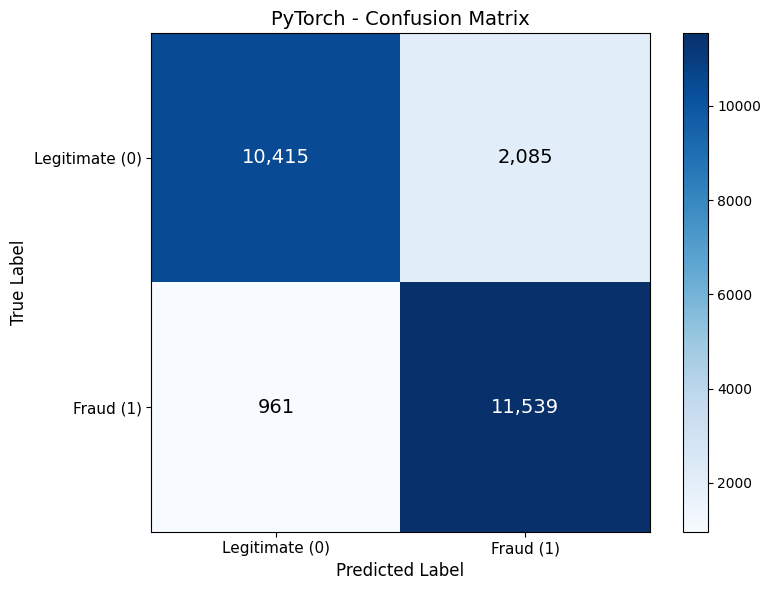


Sample Predictions (last 80 words of review):
------------------------------------------------------------

--- CORRECT ---

  True: Positive | Pred: Positive (99.6%)
  "<UNK> years after this film was <UNK> i think a lot of the fans of this movie would like to find out what happened to them as well as others who acted in this fun filled movie i certainly think..."

  True: Negative | Pred: Negative (98.4%)
  "<START> this film is unbelievable on any level it fails as an action film because no one would be fooled for a moment that the props actors and scenery are realistic it fails because even the most <UNK> ho would..."

  True: Negative | Pred: Negative (98.5%)
  "<START> terrible direction from an awful script even the dvd looked <UNK> and out of focus laughable accents all over the map unlike most of the other <UNK> i had no idea this was about boys in love in the..."

  True: Negative | Pred: Negative (98.7%)
  "to have been recorded in a back room toilet most of the dialogue is

In [3]:
# Step 3: Evaluation + Sample Predictions
"""
Show decoded review text alongside model predictions.
Demonstrates what the LSTM learned about sentiment signals.
"""

print("=" * 60)
print("[3/8] Evaluation + Sample Predictions")
print("=" * 60)

# Confusion matrix (binary)
plot_confusion_matrix(y_test, test_preds, framework=FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/confusion_matrix_baseline.png')

# Show sample predictions — decode reviews and compare to predictions
print("\nSample Predictions (last 80 words of review):")
print("-" * 60)

rng = np.random.RandomState(RANDOM_STATE)
# 4 correct + 4 incorrect
correct_mask = test_preds == y_test
correct_idx = rng.choice(np.where(correct_mask)[0], size=4, replace=False)
incorrect_idx = rng.choice(np.where(~correct_mask)[0], size=4, replace=False)

for label, indices in [("CORRECT", correct_idx), ("INCORRECT", incorrect_idx)]:
    print(f"\n--- {label} ---")
    for idx in indices:
        review_words = decode_review(X_test[idx])
        # Show last 80 words (most meaningful after pre-padding)
        words = review_words.split()[-80:]
        snippet = ' '.join(words[:40]) + '...'
        true_label = 'Positive' if y_test[idx] == 1 else 'Negative'
        pred_label = 'Positive' if test_preds[idx] == 1 else 'Negative'
        confidence = test_proba[idx] if test_preds[idx] == 1 else 1 - test_proba[idx]
        print(f"\n  True: {true_label} | Pred: {pred_label} ({confidence:.1%})")
        print(f"  \"{snippet}\"")

print(f"\n{'='*60}")
print(f"Baseline: {baseline_metrics['accuracy']:.4f} acc, {baseline_metrics['f1']:.4f} F1, {baseline_metrics['auc']:.4f} AUC")
print("=" * 60)
